# Notebook 03 – RAW Accelerometer Analysis

## Inputs
- RAW_ACCELEROMETERS.txt

## Outputs
- Clean accelerometer dataframe
- Data quality report
- Sampling frequency
- Signal visualization

## Next Notebook
Notebook 04 – RAW GPS Analysis

In [1]:
import os
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1"

print(dataset_path)

/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1


In [3]:
driver = "D1"

trip = "20151110175712-16km-D1-NORMAL1-SECONDARY"

trip_path = os.path.join(
    dataset_path,
    driver,
    trip
)

print(trip_path)

/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1/D1/20151110175712-16km-D1-NORMAL1-SECONDARY


In [4]:
files = sorted(os.listdir(trip_path))

print("Files:\n")

for file in files:
    print(file)

Files:

EVENTS_INERTIAL.txt
EVENTS_LIST_LANE_CHANGES.txt
EVENTS_LIST_LANE_CHANGES.txt~
PROC_LANE_DETECTION.txt
PROC_OPENSTREETMAP_DATA.txt
PROC_VEHICLE_DETECTION.txt
RAW_ACCELEROMETERS.txt
RAW_GPS.txt
SEMANTIC_FINAL.txt
SEMANTIC_ONLINE.txt


In [5]:
acc_path = os.path.join(trip_path, "RAW_ACCELEROMETERS.txt")

gps_path = os.path.join(trip_path, "RAW_GPS.txt")

lane_path = os.path.join(trip_path, "PROC_LANE_DETECTION.txt")

vehicle_path = os.path.join(trip_path, "PROC_VEHICLE_DETECTION.txt")

osm_path = os.path.join(trip_path, "PROC_OPENSTREETMAP_DATA.txt")

semantic_path = os.path.join(trip_path, "SEMANTIC_ONLINE.txt")

In [6]:
acc_columns = [
    "timestamp",
    "active",
    "acc_x",
    "acc_y",
    "acc_z",
    "acc_x_kf",
    "acc_y_kf",
    "acc_z_kf",
    "roll",
    "pitch",
    "yaw"
]

acc_df = pd.read_csv(
    acc_path,
    sep=r"\s+",
    header=None,
    names=acc_columns
)

acc_df.head()

,timestamp,active,acc_x,acc_y,acc_z,acc_x_kf,acc_y_kf,acc_z_kf,roll,pitch,yaw
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,0.012
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,0.012
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,0.011
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,0.011
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,0.011


In [7]:
print("Shape:", acc_df.shape)

print("\nMissing Values:\n")
print(acc_df.isnull().sum())

print("\nData Types:\n")
print(acc_df.dtypes)

Shape: (6170, 11)

Missing Values:

timestamp    0
active       0
acc_x        0
acc_y        0
acc_z        0
acc_x_kf     0
acc_y_kf     0
acc_z_kf     0
roll         0
pitch        0
yaw          0
dtype: int64

Data Types:

timestamp    float64
active         int64
acc_x        float64
acc_y        float64
acc_z        float64
acc_x_kf     float64
acc_y_kf     float64
acc_z_kf     float64
roll         float64
pitch        float64
yaw          float64
dtype: object


In [8]:
acc_df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,6170.0,318.924016,180.298864,6.940,162.575,319.010,475.08500,630.940
active,6170.0,1.000000,0.000000,1.000,1.000,1.000,1.00000,1.000
acc_x,6170.0,-0.011767,0.034041,-0.241,-0.031,-0.012,0.00800,0.171
acc_y,6170.0,-0.000352,0.035556,-0.248,-0.019,0.000,0.02000,0.173
acc_z,6170.0,-0.001793,0.021682,-0.125,-0.013,-0.001,0.01100,0.090
acc_x_kf,6170.0,-0.011786,0.024430,-0.176,-0.025,-0.012,0.00200,0.128
acc_y_kf,6170.0,-0.000361,0.031300,-0.232,-0.015,0.000,0.01600,0.149
acc_z_kf,6170.0,-0.001822,0.019112,-0.098,-0.011,-0.001,0.01000,0.083
roll,6170.0,-1.554783,0.035364,-1.662,-1.580,-1.553,-1.52800,-1.461
pitch,6170.0,-0.014719,0.041317,-0.214,-0.037,-0.007,0.01100,0.073


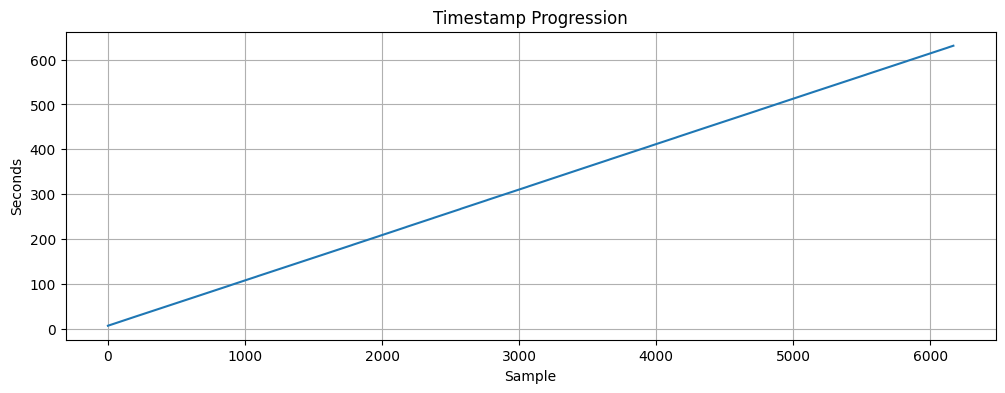

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(acc_df["timestamp"])

plt.title("Timestamp Progression")

plt.xlabel("Sample")

plt.ylabel("Seconds")

plt.grid(True)

plt.show()

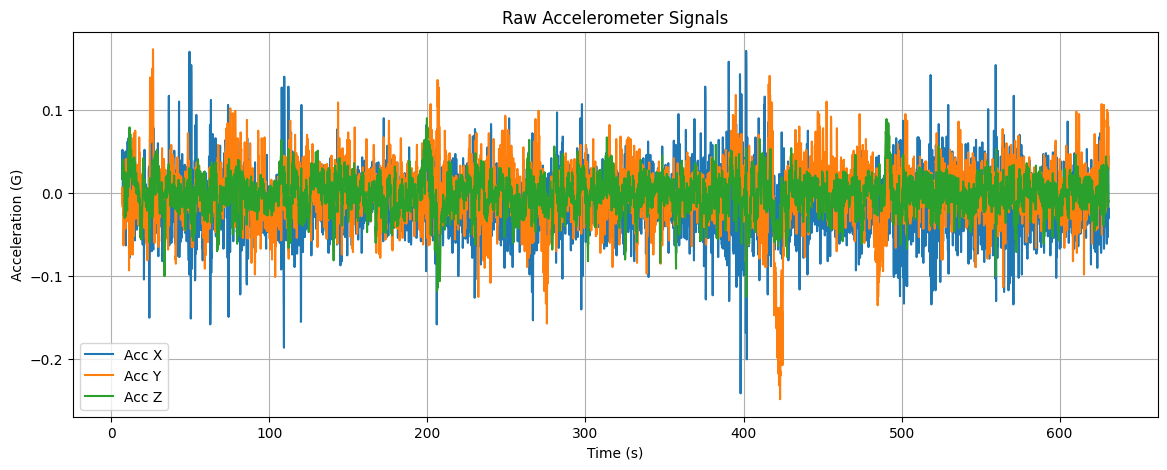

In [11]:
plt.figure(figsize=(14,5))

plt.plot(acc_df["timestamp"], acc_df["acc_x"], label="Acc X")
plt.plot(acc_df["timestamp"], acc_df["acc_y"], label="Acc Y")
plt.plot(acc_df["timestamp"], acc_df["acc_z"], label="Acc Z")

plt.title("Raw Accelerometer Signals")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (G)")

plt.legend()

plt.grid(True)

plt.show()

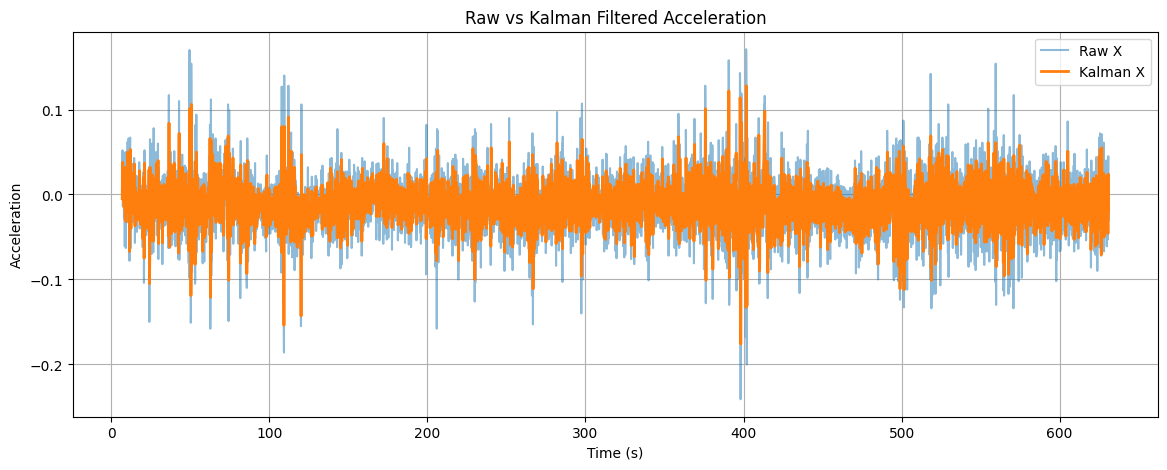

In [12]:
plt.figure(figsize=(14,5))

plt.plot(acc_df["timestamp"], acc_df["acc_x"], alpha=0.5, label="Raw X")

plt.plot(acc_df["timestamp"], acc_df["acc_x_kf"], linewidth=2, label="Kalman X")

plt.title("Raw vs Kalman Filtered Acceleration")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration")

plt.legend()

plt.grid(True)

plt.show()

In [13]:
time_diff = acc_df["timestamp"].diff()

print("Average sampling interval:", time_diff.mean())

sampling_rate = 1 / time_diff.mean()

print("Estimated sampling rate:", sampling_rate)

Average sampling interval: 0.10115091586967094
Estimated sampling rate: 9.886217948717949


# Conclusion

The RAW_ACCELEROMETERS sensor was successfully explored.

Key observations:

- The dataset contains 6170 synchronized accelerometer samples.
- No missing values were detected.
- The sampling frequency is approximately 10 Hz.
- Both raw and Kalman-filtered accelerations are available.
- The dataset is suitable for downstream feature engineering and machine learning tasks.